# Graph Neural Networks for Urban Analytics

URL: https://github.com/HUA-H124/ATUA-ASSIGNMENT2-HH.git

## 1. Data Exploration

In [46]:
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140

### 1.1 Load the data

In [47]:
import geopandas as gpd
from pathlib import Path

file_path = Path(r"C:\Users\84966\Desktop\课件材料\Advanced Topics for Urban Analytics\URBAN5160-Graph-Modelling-and-spatial-explicit-GeoAI-for-Urban-Analytics-main\Assignment\AssignmentData-LondonPM25Prediction.geojson")

gdf = gpd.read_file(file_path)

# check the first few rows of the GeoDataFrame
print(gdf.head())

# check the column names
print(gdf.columns)

# check the data structure
print(gdf.info())

     oa_code       PM25  k001_PCT  k002_PCT  k003_PCT  k004_PCT  k005_PCT  \
0  E00023264  16.037363  0.655567  0.733280  0.788337  0.809438  0.616867   
1  E00003359  15.571575  0.747233  0.539689  0.833211  0.720010  0.659997   
2  E00023266  16.068834  0.689326  0.758308  0.780265  0.787414  0.633875   
3  E00020264  18.205215  0.749280  0.701306  0.841211  0.773311  0.432955   
4  E00023263  16.128491  0.716956  0.743201  0.823621  0.783315  0.621155   

   k006_PCT  k007_RATIO  k008_PCT  ...  k052_PCT  k053_PCT  k054_PCT  \
0  0.048672    0.497994  0.116873  ...  0.801915  0.574316  0.565354   
1  0.155885    0.389216  0.387319  ...  0.731722  0.346726  0.750254   
2  0.151961    0.542225  0.000000  ...  0.789704  0.603182  0.551503   
3  0.000000    0.480711  0.000000  ...  0.712008  0.454649  0.413096   
4  0.073256    0.532274  0.000000  ...  0.752003  0.656612  0.372115   

   k055_PCT  k056_PCT  k057_PCT  k058_PCT  k059_PCT  k060_PCT  \
0  0.693873  0.607090  0.478002  0.5092

In [48]:
# check the geometry types
print(gdf.geometry.geom_type.value_counts())

# check the coordinate reference system
print(gdf.crs)

MultiPolygon    25053
Name: count, dtype: int64
EPSG:27700


After loading this dataset, a geographic data frame containing 25,053 observations and 63 variables is obtained. All the explanatory variables are of numerical type, and there are no missing values in the dataset, indicating that the data is complete and suitable for further analysis.
The geometric type is "polygons", which means that each observation represents a spatial area. The coordinate reference system used by the dataset is the British National Grid.

### 1.2 PM2.5 Distribution

count    25053.000000
mean        15.975608
std          0.783971
min         14.283266
25%         15.403583
50%         15.846878
75%         16.428663
max         21.100099
Name: PM25, dtype: float64


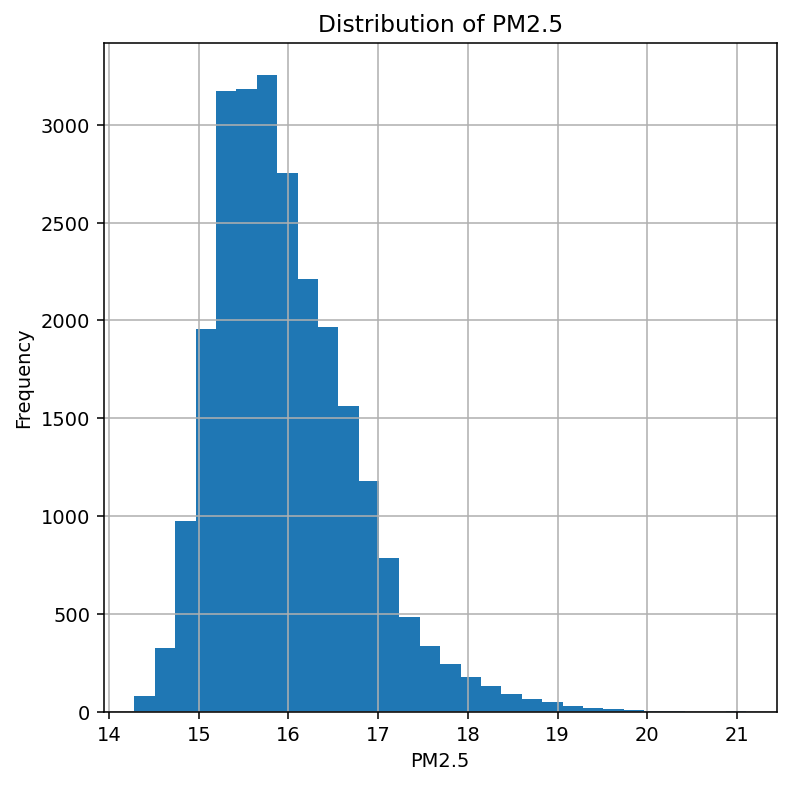

In [87]:
# distribution of PM2.5
print(gdf['PM25'].describe())

plt.figure(figsize=(6.2, 6.2)) 
gdf['PM25'].hist(bins=30)

plt.title("Distribution of PM2.5")
plt.xlabel("PM2.5")
plt.ylabel("Frequency")

plt.show()

The distribution of PM2.5 values shows a slightly right-skewed pattern, which illustrated in the histogram. The majority of the values are concentrated between 15 and 17, only a few higher values exceeding 18. This indicates that although the pollution levels in most areas are roughly the same, there are still a few areas where the PM2.5 concentration is much higher.

### 1.3 Map of PM2.5

<Figure size 868x868 with 0 Axes>

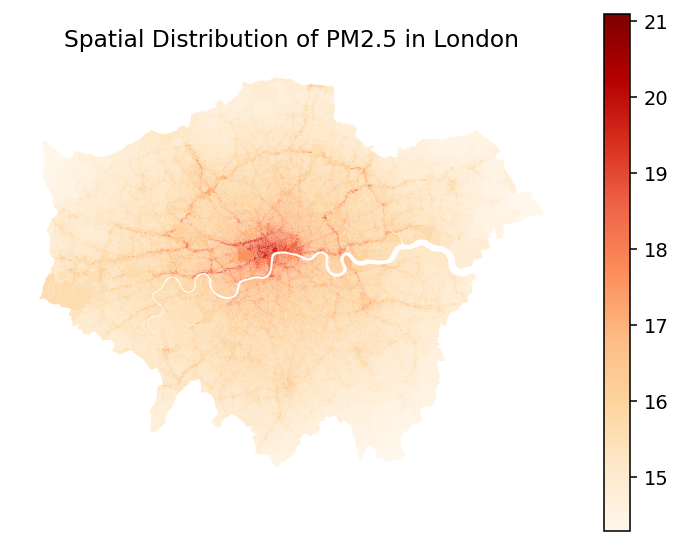

In [50]:
plt.figure(figsize=(6.2, 6.2))
gdf.plot(column='PM25', cmap='OrRd', legend=True)
plt.title("Spatial Distribution of PM2.5 in London")
plt.axis('off')
plt.show()

This spatial distribution map shows the regional variations in PM2.5 concentrations in the London area. The areas with higher pollution levels are concentrated in the central part of London, which is located in the densely built-up and highly trafficked areas. Lower concentration values were observed in the outer suburban regions. The spatial distribution map indicates that urban density and emissions related to transportation are likely to be important factors causing air pollution.

In [51]:
print(gdf.columns)

Index(['oa_code', 'PM25', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT',
       'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT',
       'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT', 'k014_PCT', 'k015_PCT',
       'k016_PCT', 'k017_PCT', 'k018_PCT', 'k019_PCT', 'k020_PCT', 'k021_PCT',
       'k022_PCT', 'k023_PCT', 'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT',
       'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT', 'k032_PCT', 'k033_PCT',
       'k034_PCT', 'k035_RATIO', 'k036_PCT', 'k037_PCT', 'k038_PCT',
       'k039_PCT', 'k040_PCT', 'k041_PCT', 'k042_PCT', 'k043_PCT', 'k044_PCT',
       'k045_PCT', 'k046_PCT', 'k047_PCT', 'k048_PCT', 'k049_PCT', 'k050_PCT',
       'k051_PCT', 'k052_PCT', 'k053_PCT', 'k054_PCT', 'k055_PCT', 'k056_PCT',
       'k057_PCT', 'k058_PCT', 'k059_PCT', 'k060_PCT', 'geometry'],
      dtype='object')


In [52]:
# delete the 'id' column if it exists
exclude_cols = ['PM25', 'geometry']

features = [col for col in gdf.columns if col not in exclude_cols]

print("Selected features:")
print(features)

# select only numeric features for modeling
numeric_features = gdf[features].select_dtypes(include=['float64', 'int64']).columns.tolist()

print("Numeric features:")
print(numeric_features)

Selected features:
['oa_code', 'k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT', 'k017_PCT', 'k018_PCT', 'k019_PCT', 'k020_PCT', 'k021_PCT', 'k022_PCT', 'k023_PCT', 'k024_PCT', 'k025_PCT', 'k026_PCT', 'k027_PCT', 'k028_PCT', 'k029_PCT', 'k030_PCT', 'k031_PCT', 'k032_PCT', 'k033_PCT', 'k034_PCT', 'k035_RATIO', 'k036_PCT', 'k037_PCT', 'k038_PCT', 'k039_PCT', 'k040_PCT', 'k041_PCT', 'k042_PCT', 'k043_PCT', 'k044_PCT', 'k045_PCT', 'k046_PCT', 'k047_PCT', 'k048_PCT', 'k049_PCT', 'k050_PCT', 'k051_PCT', 'k052_PCT', 'k053_PCT', 'k054_PCT', 'k055_PCT', 'k056_PCT', 'k057_PCT', 'k058_PCT', 'k059_PCT', 'k060_PCT']
Numeric features:
['k001_PCT', 'k002_PCT', 'k003_PCT', 'k004_PCT', 'k005_PCT', 'k006_PCT', 'k007_RATIO', 'k008_PCT', 'k009_PCT', 'k010_PCT', 'k011_PCT', 'k012_PCT', 'k013_PCT', 'k014_PCT', 'k015_PCT', 'k016_PCT', 'k017_PCT', 'k018_PCT', 'k019_PC

### 1.4 Feature Distribution

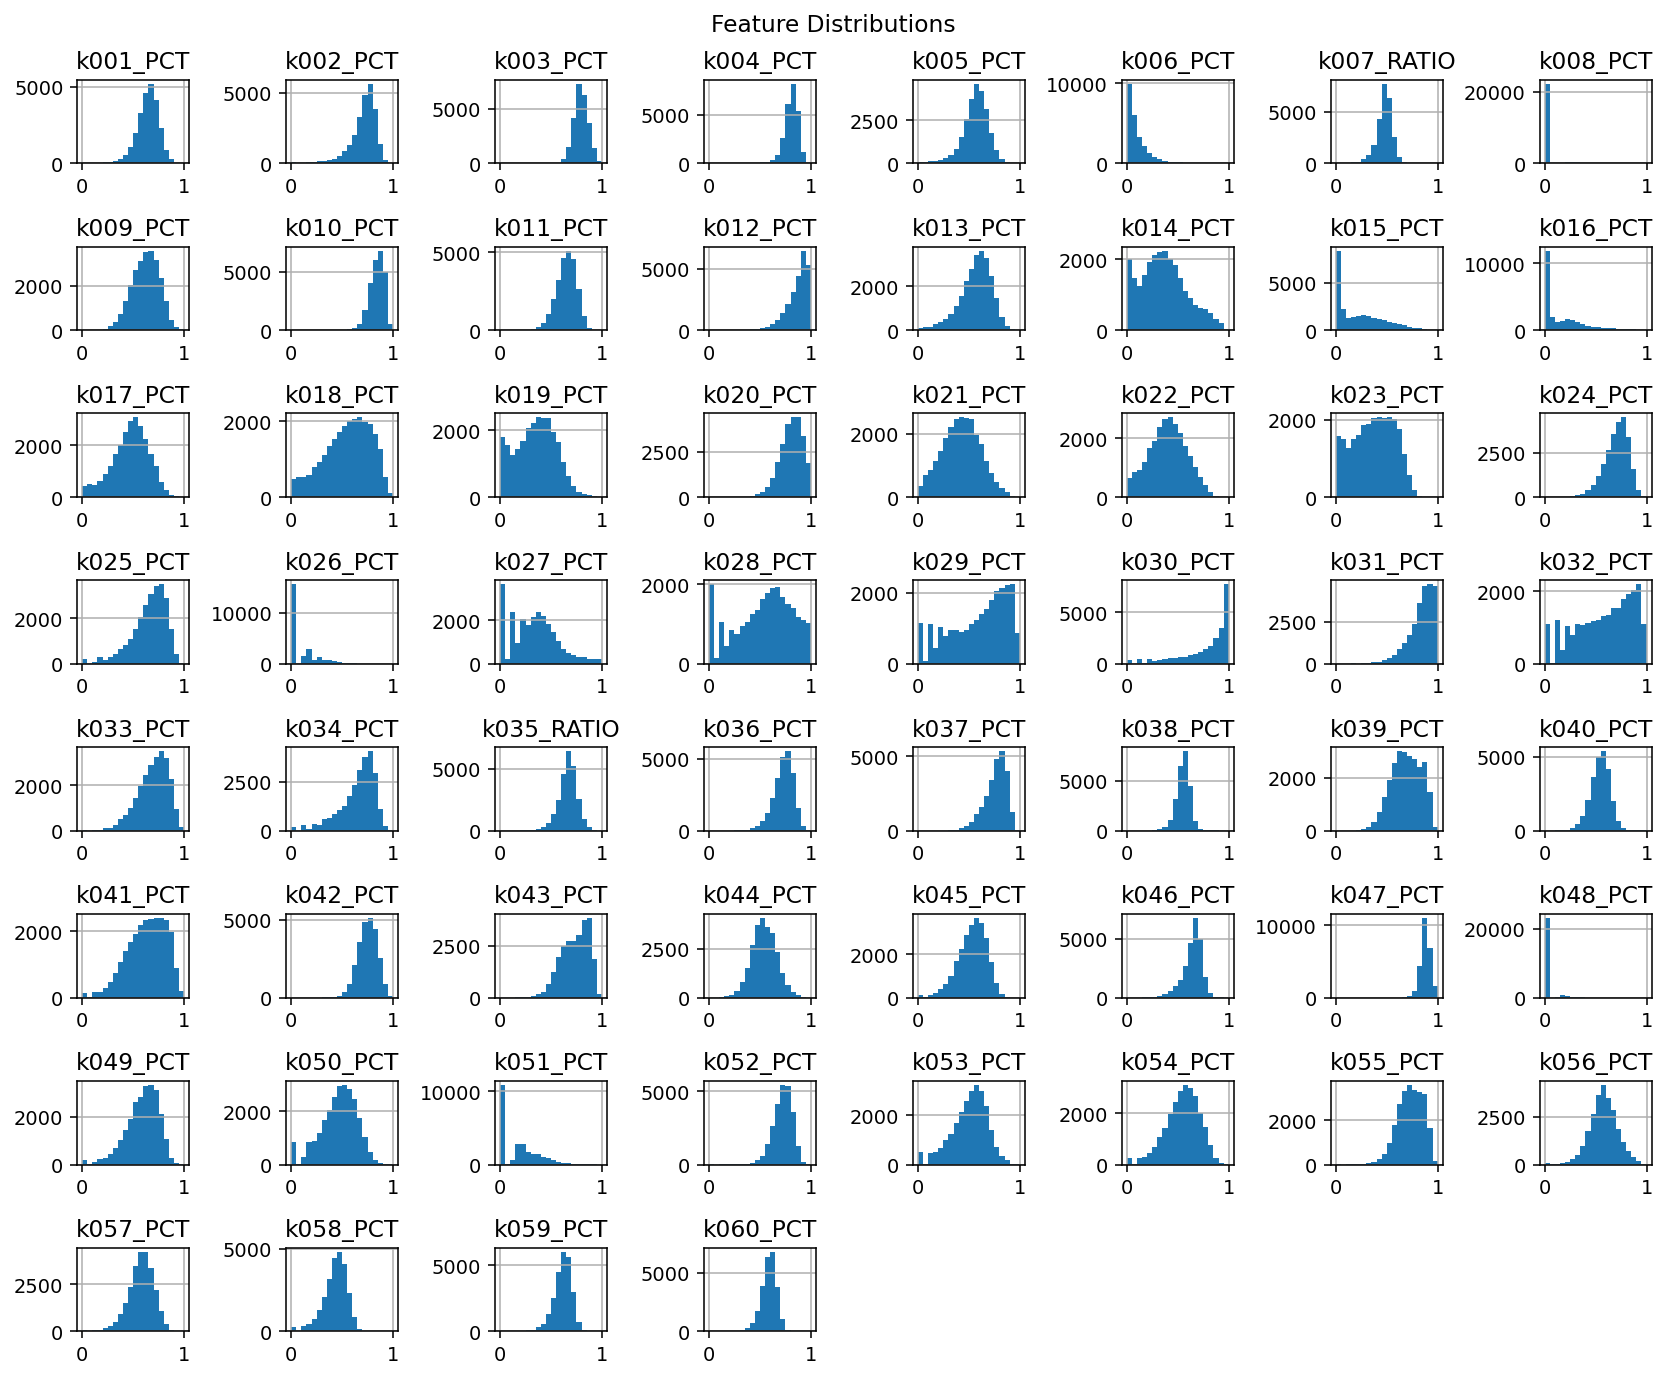

In [89]:
gdf[numeric_features].hist(figsize=(12, 10), bins=20)

plt.suptitle("Feature Distributions")
plt.tight_layout() 
plt.show()

Most of the feature values are standardized within the range of 0 to 1, indicating that they represent proportions or percentages. Several variables exhibit skewed distributions, with some clustering around 0 or 1, suggesting that their characteristics are imbalanced or sparse. All numerical attributes were selected as input features because they encompassed the characteristics relevant to PM2.5 prediction.

## 2. Graph Construction

### 2.1 Queen Adjacency Graph

In [54]:
import geopandas as gpd
from libpysal.weights import Queen

w_queen = Queen.from_dataframe(gdf)
print(w_queen)
print("Number of nodes:", w_queen.n)
print("Number of edges:", w_queen.s0 / 2)

C:\Users\84966\AppData\Local\Temp\ipykernel_28316\3966335337.py:4: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w_queen = Queen.from_dataframe(gdf)


Number of nodes: 25053
Number of edges: 75967.0


In [55]:
import networkx as nx

G_queen = w_queen.to_networkx()

print(G_queen.number_of_nodes())
print(G_queen.number_of_edges())

25053
75967


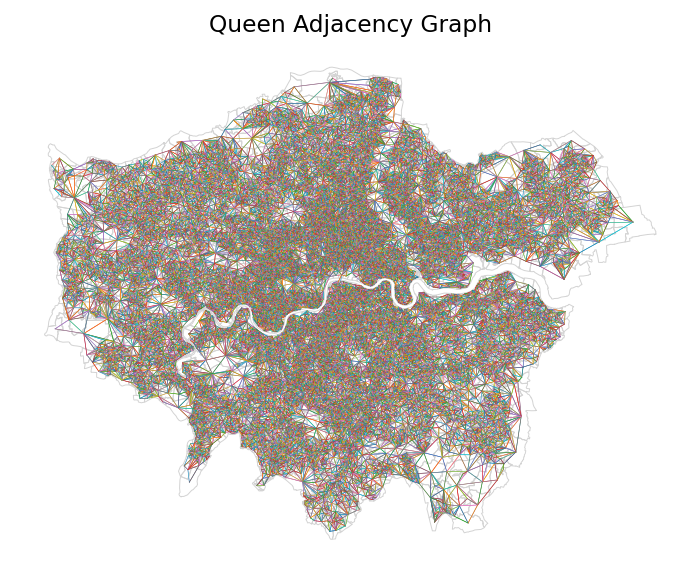

In [56]:
import matplotlib.pyplot as plt

# project to a metric CRS for accurate distance calculations
gdf_proj = gdf.to_crs(epsg=27700)

# get centroids of polygons for plotting
centroids = gdf_proj.geometry.centroid
coords = list(zip(centroids.x, centroids.y))

plt.figure(figsize=(6.2, 6.2))

# plot the boundaries of the polygons
gdf_proj.boundary.plot(ax=plt.gca(), color='lightgrey', linewidth=0.5)

# plot the edges of the Queen graph
for i, neighbors in w_queen.neighbors.items():
    for j in neighbors:
        x = [coords[i][0], coords[j][0]]
        y = [coords[i][1], coords[j][1]]
        plt.plot(x, y, linewidth=0.3)

plt.title("Queen Adjacency Graph")
plt.axis('off')
plt.show()

The adjacency graph is constructed using the queen adjacency principle, where nodes are connected if their corresponding polygons share boundaries or vertices. This approach reflects true geographical relationships and is suitable for regional data.

### 2.2 K-nearest Neighbour Graph

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from libpysal.weights import KNN

# extract centroids
coords = np.column_stack((gdf.geometry.centroid.x, gdf.geometry.centroid.y))

# build KNN graph 
k = 5
knn = KNN.from_array(coords, k=k)

print(knn)

In [58]:
import networkx as nx

# create NetworkX graph
G = knn.to_networkx()

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 25053
Number of edges: 125265


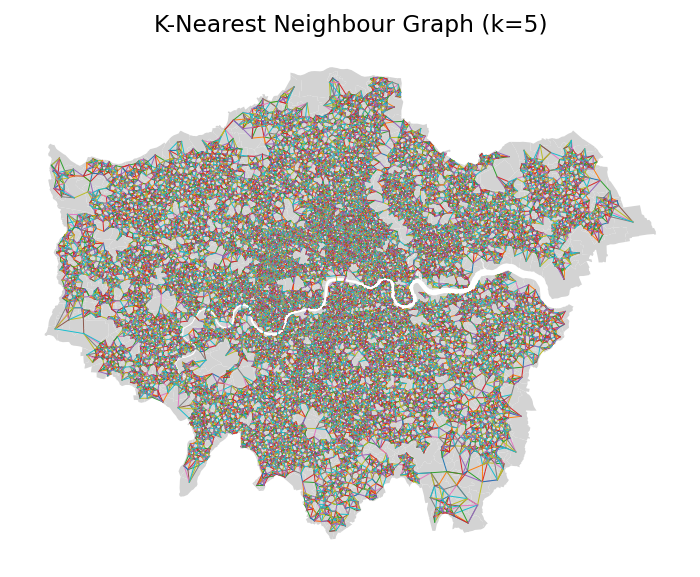

In [59]:
plt.figure(figsize=(6.2, 6.2))

# draw nodes
gdf.plot(ax=plt.gca(), color='lightgrey', markersize=5)

# draw edges
for i, neighbors in knn.neighbors.items():
    for j in neighbors:
        x = [coords[i][0], coords[j][0]]
        y = [coords[i][1], coords[j][1]]
        plt.plot(x, y, linewidth=0.5)

plt.title("K-Nearest Neighbour Graph (k=5)")
plt.axis('off')
plt.show()

The KNN graph is constructed by connecting each output area to its five nearest neighbours based on centroid distance. The choice of 𝑘=5 balances capturing local spatial information while avoiding overly dense connections that may introduce noise or increase computational complexity. By simulating the relationship based on distance, the KNN graph can effectively capture spatial dependence, as air pollution may spread beyond the immediate adjacent areas.

### 2.3 Summary

The report compares adjacency and KNN graph constructions. While adjacency preserves true geographical relationships, the KNN graph provides more balanced connectivity. The reason for choosing KNN is that it has a unified structure, enhanced stability, and the ability to capture spatial influences based on distance.

## 3. Graph Neural Network Model

### 3.1 Graph Construction

In [60]:
import torch
import numpy as np
from torch_geometric.data import Data
from sklearn.preprocessing import StandardScaler

# target variable
target_col = 'PM25'  

exclude_cols = ['geometry', target_col]
feature_cols = [col for col in gdf.columns if col not in exclude_cols]

# numeric features
X = gdf[feature_cols].select_dtypes(include=['float64', 'int64']).values
y = gdf[target_col].values.reshape(-1, 1)

# standardize features
x_scaler = StandardScaler()
X = x_scaler.fit_transform(X)

y_scaler = StandardScaler()  
y_scaled = y_scaler.fit_transform(y)

# tensor
x = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y_scaled, dtype=torch.float32)

In [61]:
from libpysal.weights import KNN

# project to a metric CRS
gdf_proj = gdf.to_crs(epsg=27700)

coords = np.column_stack((
    gdf_proj.geometry.centroid.x,
    gdf_proj.geometry.centroid.y
))

k = 5
knn = KNN.from_array(coords, k=k)

# KNN weights
edges = []
for i, neighbors in knn.neighbors.items():
    for j in neighbors:
        edges.append((i, j))
        edges.append((j, i))

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

The report uses the GNN model to predict PM2.5 concentration. The model uses PyTorch Geometric, where each output area is represented as a node, and spatial dependencies are encoded through the edges in the graph. A KNN-based spatial graph is constructed using the British National Grid Coordinate System, where each node is connected to its five nearest neighbours, with reciprocal edges forming an undirected graph.

All numerical features are standardized using z-score, and the PM2.5 values are also standardized during training and inversely transformed during evaluation to ensure numerical stability and comparability.

### 3.2 Data Processing

In [62]:
data = Data(x=x, edge_index=edge_index, y=y)

print(data)

Data(x=[25053, 60], edge_index=[2, 250530], y=[25053, 1])


In [63]:
num_nodes = data.num_nodes
indices = np.arange(num_nodes)

np.random.seed(42)
np.random.shuffle(indices)

train_size = int(0.6 * num_nodes)
val_size = int(0.2 * num_nodes)

train_idx = indices[:train_size]
val_idx = indices[train_size:train_size+val_size]
test_idx = indices[train_size+val_size:]

train_mask = torch.zeros(num_nodes, dtype=torch.bool)
val_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

train_mask[train_idx] = True
val_mask[val_idx] = True
test_mask[test_idx] = True

data.train_mask = train_mask
data.val_mask = val_mask
data.test_mask = test_mask

The dataset was randomly divided into 60% of training, 20% of validation, and 20% of testing subsets using boolean masks, while preserving the underlying graph structure for message passing. This approach allows the model to learn from the training nodes and be evaluated on unseen nodes without altering the connectivity of the graph. The split was performed using a fixed random seed to ensure reproducibility of results.

### 3.3 Model Architecture and Training Procedure

In [64]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, SAGEConv

# GCN model
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=32):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv2(x, edge_index)
        return x

# GraphSAGE model
class GraphSAGE(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels=32):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=0.2, training=self.training)
        
        x = self.conv2(x, edge_index)
        return x


In [65]:
def train_model(model, data, epochs=200):
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = torch.nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        out = model(data)
        loss = loss_fn(out[data.train_mask], data.y[data.train_mask])

        loss.backward()
        optimizer.step()

        if epoch % 20 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return model

The report separately constructed two neural network models, namely GCN and GraphSAGE. Both of these models consist of two layers. The first layer generates hidden node representations, which are then processed through ReLU activation and dropout (p = 0.2). The second layer outputs a single regression value for PM2.5 prediction. The difference between GraphSAGE and GCN lies in their aggregation mechanism, which uses neighborhood feature aggregation to calculate node embeddings.

### 3.4 Results

In [66]:
from sklearn.metrics import mean_squared_error, r2_score

@torch.no_grad()
def evaluate(model, data):
    model.eval()
    pred = model(data).cpu().numpy()

    # inverse transform predictions and true values
    pred = y_scaler.inverse_transform(pred)
    y_true = y_scaler.inverse_transform(data.y.cpu().numpy())

    def metrics(mask):
        idx = mask.cpu().numpy()
        rmse = np.sqrt(mean_squared_error(y_true[idx], pred[idx]))
        r2 = r2_score(y_true[idx], pred[idx])
        return rmse, r2

    return {
        "train": metrics(data.train_mask),
        "val": metrics(data.val_mask),
        "test": metrics(data.test_mask)
    }

# GCN training and evaluation
gcn = GCN(in_channels=data.num_features)
gcn = train_model(gcn, data)

gcn_results = evaluate(gcn, data)
print("\nGCN Results:", gcn_results)

# GraphSAGE training and evaluation
sage = GraphSAGE(in_channels=data.num_features)
sage = train_model(sage, data)

sage_results = evaluate(sage, data)
print("\nGraphSAGE Results:", sage_results)

Epoch 0, Loss: 2.0900
Epoch 20, Loss: 0.2651
Epoch 40, Loss: 0.2026
Epoch 60, Loss: 0.1819
Epoch 80, Loss: 0.1731
Epoch 100, Loss: 0.1697
Epoch 120, Loss: 0.1633
Epoch 140, Loss: 0.1618
Epoch 160, Loss: 0.1587
Epoch 180, Loss: 0.1553

GCN Results: {'train': (np.float64(0.2983576867594455), 0.8547642230987549), 'val': (np.float64(0.31224396468973525), 0.8381020426750183), 'test': (np.float64(0.31461506577207543), 0.8433351516723633)}
Epoch 0, Loss: 1.3508
Epoch 20, Loss: 0.2283
Epoch 40, Loss: 0.1825
Epoch 60, Loss: 0.1685
Epoch 80, Loss: 0.1563
Epoch 100, Loss: 0.1507
Epoch 120, Loss: 0.1451
Epoch 140, Loss: 0.1399
Epoch 160, Loss: 0.1389
Epoch 180, Loss: 0.1326

GraphSAGE Results: {'train': (np.float64(0.27354416810252874), 0.8779172897338867), 'val': (np.float64(0.2978361907494416), 0.8526981472969055), 'test': (np.float64(0.299322766085542), 0.8581948280334473)}


In [90]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X_np = X
y_np = gdf['PM25'].values

lr = LinearRegression()
lr.fit(X_np[train_idx], y_np[train_idx])

y_true = y_np[test_idx]
y_pred = lr.predict(X_np[test_idx])

rmse_lr = np.sqrt(mean_squared_error(y_true, y_pred))
r2_lr = r2_score(y_true, y_pred)

print("Linear Regression")
print("RMSE:", rmse_lr)
print("R²:", r2_lr)

Linear Regression
RMSE: 0.39461003211881296
R²: 0.7535386932274705


The results show that GraphSAGE outperforms GCN, achieving a lower RMSE of 0.299 and a higher R² of 0.858, compared to GCN with an RMSE of 0.315 and an R² of 0.843. Both models also outperform linear regression, which has a higher RMSE of 0.395 and a lower R² of 0.754.

This indicates that PM2.5 prediction benefits from modelling non-linear relationships and incorporating spatial information. However, the use of a random train-test split may lead to optimistic results due to spatial autocorrelation.

## 4. Results and Interpretation

### 4.1 Model Performance

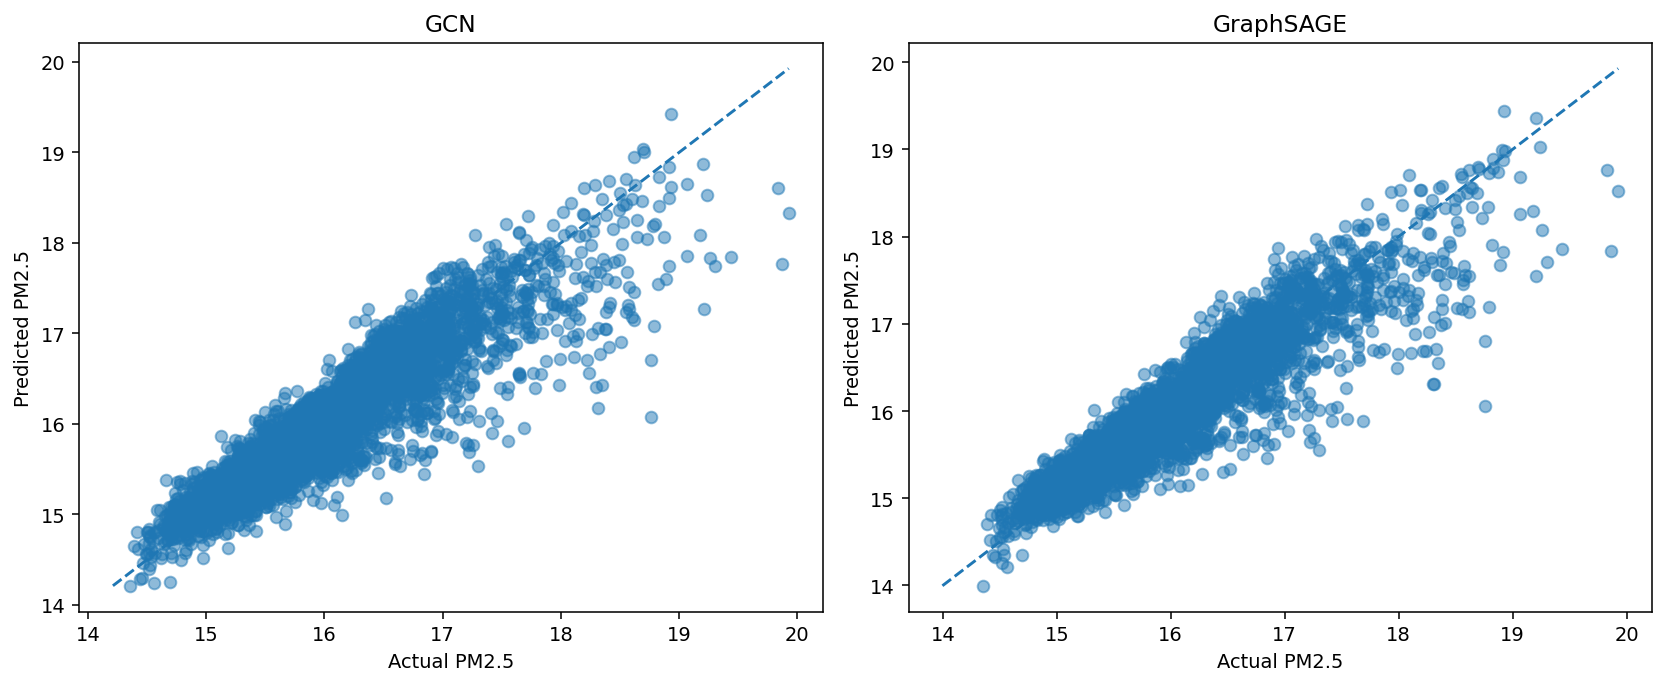

In [76]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import mean_squared_error, r2_score

@torch.no_grad()
def plot_model_comparison(gcn_model, sage_model, data, y_scaler):
    gcn_model.eval()
    sage_model.eval()

    # GCN predictions
    gcn_pred = gcn_model(data).cpu().numpy()
    y_true = data.y.cpu().numpy()
    gcn_pred = y_scaler.inverse_transform(gcn_pred).ravel()
    y_true = y_scaler.inverse_transform(y_true).ravel()
    test_mask = data.test_mask.cpu().numpy()
    y_test = y_true[test_mask]
    gcn_pred_test = gcn_pred[test_mask]

    # GraphSAGE predictions
    sage_pred = sage_model(data).cpu().numpy()
    sage_pred = y_scaler.inverse_transform(sage_pred).ravel()
    sage_pred_test = sage_pred[test_mask]
    rmse_gcn = np.sqrt(mean_squared_error(y_test, gcn_pred_test))
    r2_gcn = r2_score(y_test, gcn_pred_test)

    rmse_sage = np.sqrt(mean_squared_error(y_test, sage_pred_test))
    r2_sage = r2_score(y_test, sage_pred_test)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # GCN subplot
    axes[0].scatter(y_test, gcn_pred_test, alpha=0.5)
    min_val = min(y_test.min(), gcn_pred_test.min())
    max_val = max(y_test.max(), gcn_pred_test.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], '--')
    axes[0].set_title(f"GCN")
    axes[0].set_xlabel("Actual PM2.5")
    axes[0].set_ylabel("Predicted PM2.5")

    # GraphSAGE subplot
    axes[1].scatter(y_test, sage_pred_test, alpha=0.5)
    min_val = min(y_test.min(), sage_pred_test.min())
    max_val = max(y_test.max(), sage_pred_test.max())
    axes[1].plot([min_val, max_val], [min_val, max_val], '--')
    axes[1].set_title(f"GraphSAGE")
    axes[1].set_xlabel("Actual PM2.5")
    axes[1].set_ylabel("Predicted PM2.5")

    # Adjust layout
    plt.tight_layout()
    plt.show()

# Run the function
plot_model_comparison(gcn, sage, data, y_scaler)

The graphs show a positive relationship, indicating that both GCN and GraphSAGE capture the trend of PM2.5. However, there is spread around the 45° line, which suggesting reduced accuracy for extreme pollution levels. GraphSAGE graph performs better, with predictions closer to the reference line.

### 4.2 Spatial Distribution

<Figure size 868x868 with 0 Axes>

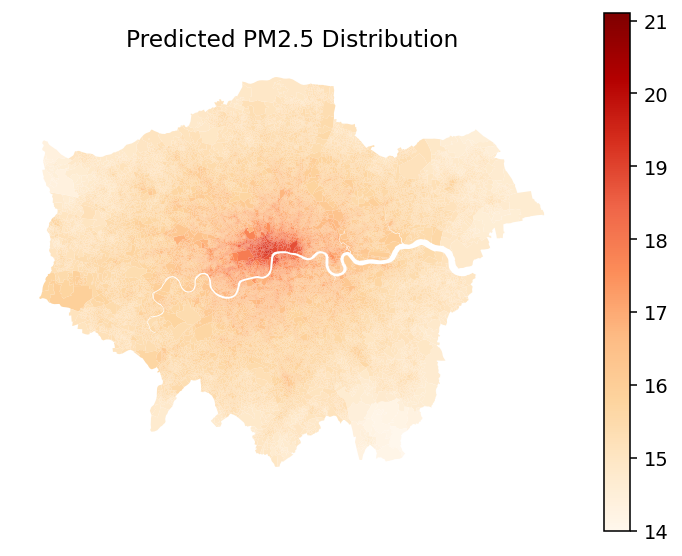

In [80]:
@torch.no_grad()
def get_full_predictions(model, data, y_scaler):
    model.eval()
    pred = model(data).cpu().numpy()
    pred = y_scaler.inverse_transform(pred)
    return pred.ravel()

# generate predicted PM2.5 values in the original scale
pred_pm25 = get_full_predictions(sage, data, y_scaler)

# add predicted values to GeoDataFrame
gdf = gdf.copy()
gdf['pred_PM25'] = pred_pm25

# use the same value range as the actual PM2.5 map
vmin = min(gdf['PM25'].min(), gdf['pred_PM25'].min())
vmax = max(gdf['PM25'].max(), gdf['pred_PM25'].max())

plt.figure(figsize=(6.2, 6.2))
gdf.plot(column='pred_PM25', cmap='OrRd', legend=True, vmin=vmin, vmax=vmax)
plt.title("Predicted PM2.5 Distribution")
plt.axis('off')
plt.show()

The predicted graph shows higher PM 2.5 in central London and lower PM2.5 in outer areas, consistent with the observed pattern. This indicates that the model captures the main spatial structure well.

### 4.3 Actual and Predicted PM2.5 Comparison

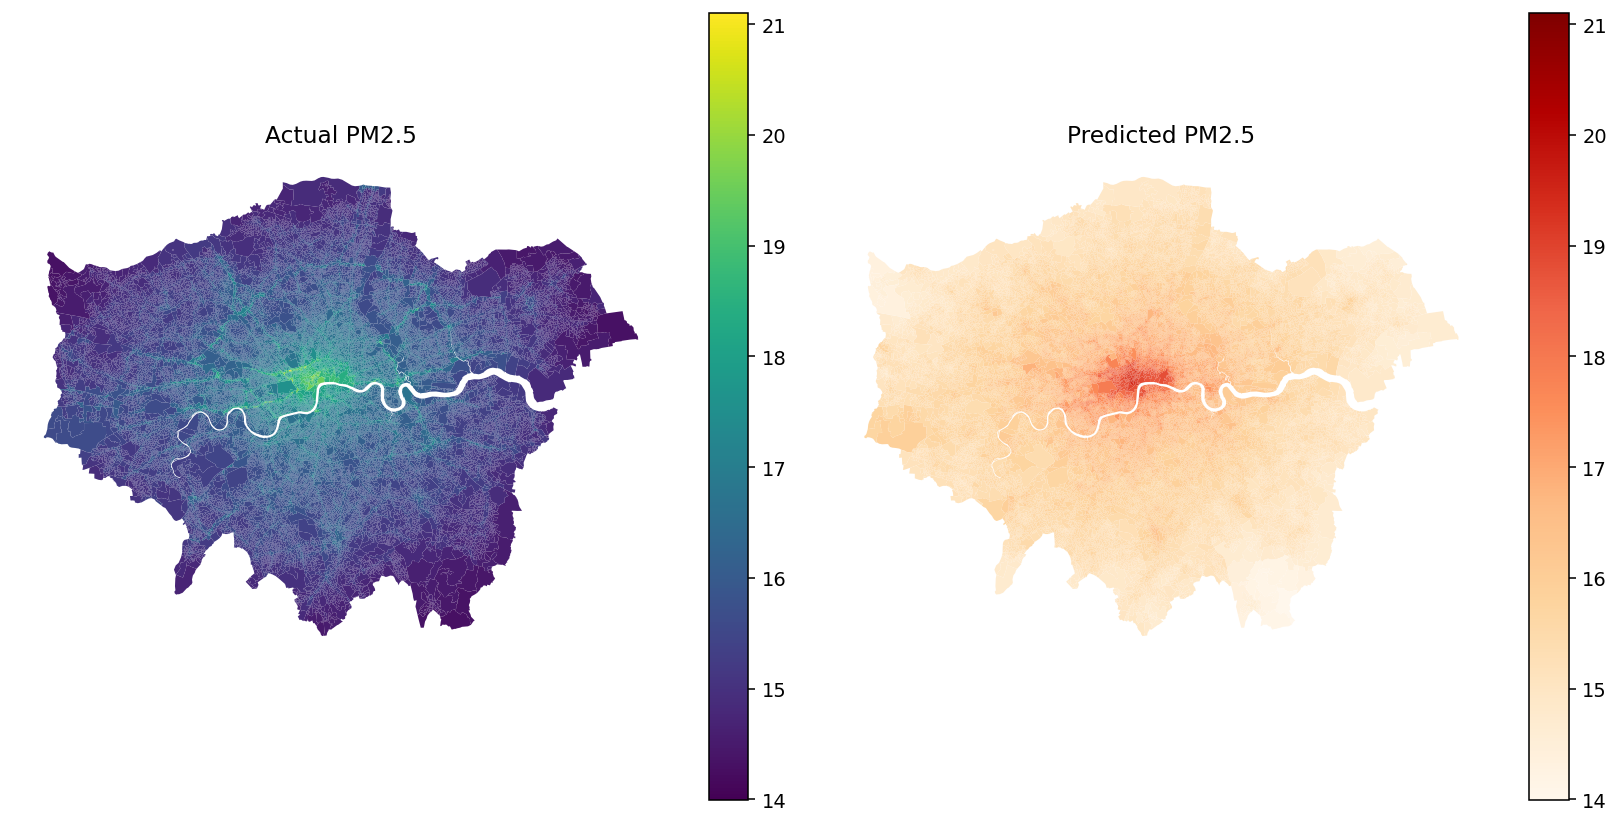

In [79]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# define shared color scale
vmin = min(gdf['PM25'].min(), gdf['pred_PM25'].min())
vmax = max(gdf['PM25'].max(), gdf['pred_PM25'].max())

# actual PM2.5
gdf.plot(column='PM25', ax=axes[0], cmap='viridis',
         legend=True, vmin=vmin, vmax=vmax)
axes[0].set_title("Actual PM2.5")

# predicted PM2.5
gdf.plot(column='pred_PM25', ax=axes[1], cmap='OrRd',
         legend=True, vmin=vmin, vmax=vmax)
axes[1].set_title("Predicted PM2.5")

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

Both graphs show a similar spatial pattern, with higher concentrations in central London and lower values in outer areas, indicating that the model successfully captures the overall spatial structure. The predicted map appears smoother than the observed map, with less local variation.

### 4.4 Prediction Error

<Figure size 868x868 with 0 Axes>

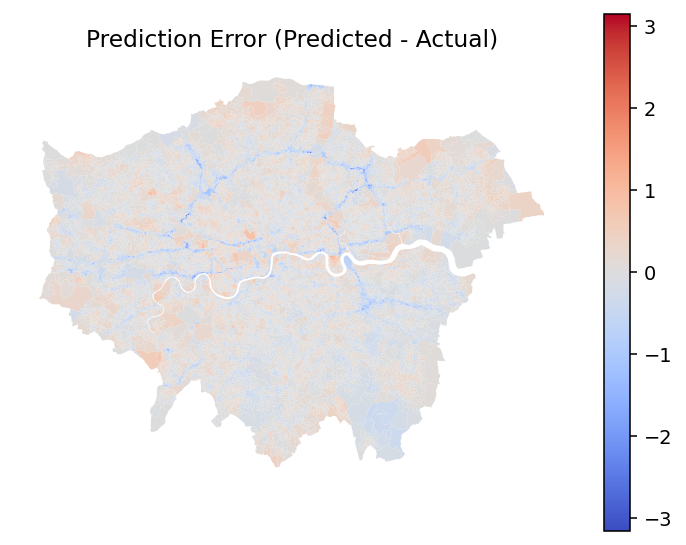

In [81]:
# compute error
gdf['error'] = gdf['pred_PM25'] - gdf['PM25']

# define symmetric color range around 0
err_max = np.abs(gdf['error']).max()

plt.figure(figsize=(6.2, 6.2))
gdf.plot(column='error', cmap='coolwarm',
         legend=True, vmin=-err_max, vmax=err_max)

plt.title("Prediction Error (Predicted - Actual)")
plt.axis('off')
plt.show()

This error map reveals the regional distribution characteristics of the model's performance. The model tends to overestimate the PM2.5 content in the central area, while underestimating it in the surrounding areas. This indicates the presence of a smoothing effect, where extreme values have been somewhat adjusted.

### 4.5 Summary

Using the graph structure enables the model to integrate information from adjacent regions, thereby improving the accuracy of PM2.5 prediction. This is because this indicator has a distinct spatial autocorrelation. This makes the prediction results more coherent spatially. The KNN graph may not fully reflect the spatial processes in the real world. The model generates overly smooth results and does not take into account the time-varying factors.

## word count

In [91]:
import io
import os
from nbformat import current

for root, dirs, files in os.walk("."):
    for file in files:
        if file.endswith(".ipynb") and not file.endswith("checkpoint.ipynb"):
            print(os.path.join(root, file))

            with io.open(os.path.join(root, file), 'r', encoding='utf-8') as f:
                nb = current.read(f, 'json')

            word_count_markdown = 0
            word_count_heading = 0
            word_count_code = 0

            for cell in nb.worksheets[0].cells:
                if cell.cell_type == "markdown":
                    word_count_markdown += len(cell['source'].replace('#', '').lstrip().split())
                elif cell.cell_type == "heading":
                    word_count_heading += len(cell['source'].replace('#', '').lstrip().split())
                elif cell.cell_type == "code":
                    word_count_code += len(cell['input'].replace('#', '').lstrip().split())

            print("{} Words in notebooks' markdown".format(word_count_markdown))
            print("{} Words in notebooks' heading".format(word_count_heading))
            print("{} Words in notebooks' code".format(word_count_code))

            break  

    break  

.\ATUA_Assignment2.ipynb
948 Words in notebooks' markdown
78 Words in notebooks' heading
1135 Words in notebooks' code
